In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

from langdetect import detect
from transformers import pipeline
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans # SpectralClustering тяжел для перебора, KMeans быстрее для поиска K

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Загрузка и первичный анализ

In [2]:
# 1. Загрузка
df = pd.read_csv('Video scripts.csv', encoding='latin-1')
display(df.head(5))
display(df.shape)

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo..."
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu..."
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...


(3027, 6)

In [3]:
# Обрабатываем пустые транскрипции
df['Transcript'] = df['Transcript'].fillna("")
display(df.shape)

(3027, 6)

# 2. Распределение revenue и лайков

## Лайки

In [4]:
# Выведет долю (от 0% до 100%) для каждого уникального значения в 'likes'
share = df['Likes Count'].value_counts(normalize=True)*100
share.head(15)

0     28.278824
1     13.214404
2      8.655434
3      6.309878
4      4.757185
5      3.964321
6      3.105385
7      2.940205
8      2.180377
9      1.618764
11     1.585728
10     1.288404
14     1.057152
12     0.958044
13     0.858936
Name: Likes Count, dtype: float64

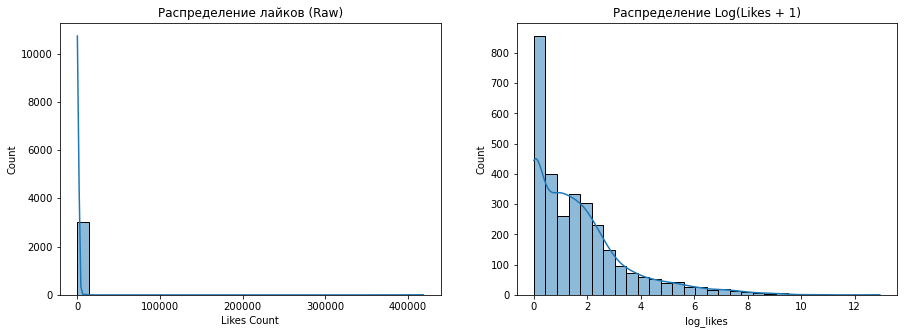

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Обычное распределение
sns.histplot(df['Likes Count'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Распределение лайков (Raw)')

# Логарифмическое распределение
df['log_likes'] = np.log1p(df['Likes Count'])
sns.histplot(df['log_likes'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Распределение Log(Likes + 1)')

plt.show()

## Revenue

In [6]:
# Определяем границы (bins) и названия категорий (labels)
bins = [0, 0.001, 1000, 10000, np.inf]
labels = ['Zero', 'Low', 'Mid', 'High']

# Создаем колонку (right=False делает интервал [0, 1000), т.е. до 999 включительно)
df['revenue_category'] = pd.cut(df['Video Revenue'], bins=bins, labels=labels, right=False)
df.head()

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,log_likes,revenue_category
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",12.944296,High
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,8.465900,High
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",7.042286,High
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,8.927977,High
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,8.840580,High


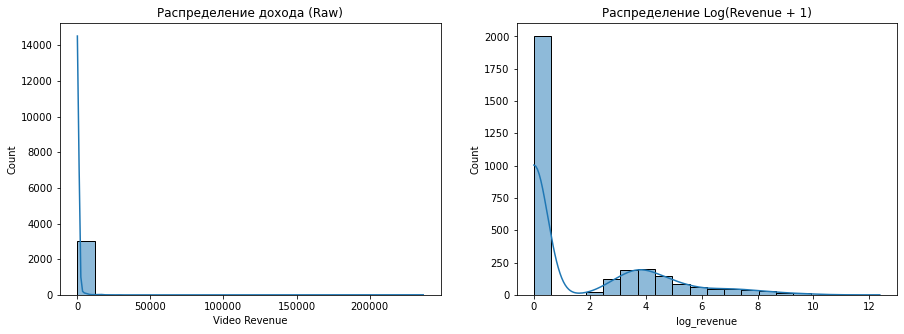

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Обычное распределение
sns.histplot(df['Video Revenue'], bins=20, kde=True, ax=ax[0])
ax[0].set_title('Распределение дохода (Raw)')

# Логарифмическое распределение
df['log_revenue'] = np.log1p(df['Video Revenue'])
sns.histplot(df['log_revenue'], bins=20, kde=True, ax=ax[1])
ax[1].set_title('Распределение Log(Revenue + 1)')

plt.show()

## Распределение классов

In [8]:
share = df['revenue_category'].value_counts(normalize=True)*100
share

Zero    66.171127
Low     29.369012
Mid      3.832177
High     0.627684
Name: revenue_category, dtype: float64

# 3. Определение языка комментария

In [9]:
# --- 1. Определение языка ---
def get_lang(text):
    try:
        return detect(text)
    except:
        return 'unknown'

df['lang'] = df['Transcript'].apply(get_lang)
df.head()

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,log_likes,revenue_category,log_revenue,lang
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",12.944296,High,12.374768,en
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,8.465900,High,10.808800,es
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",7.042286,High,10.580211,es
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,8.927977,High,10.230364,en
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,8.840580,High,10.092160,es


In [10]:
share = df['lang'].value_counts(normalize=True)*100
share

en         63.924678
es         34.291378
de          0.363396
pt          0.297324
fr          0.231252
so          0.165180
af          0.165180
unknown     0.165180
nl          0.132144
it          0.099108
id          0.033036
sw          0.033036
hr          0.033036
et          0.033036
vi          0.033036
Name: lang, dtype: float64

## Оставляем только английский и испанский языки (упрощение контентных фичей) 

In [11]:
df = df[df['lang'].isin(['en', 'es'])]
df = df.reset_index(drop=True)
df.shape

(2973, 10)

In [12]:
# Создаем бинарные фичи для основных языков (One-Hot Encoding)
lang_features = pd.get_dummies(df['lang'], prefix='lang')

In [13]:
df = pd.concat([df, lang_features['lang_en']], axis=1)
df.head()

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,log_likes,revenue_category,log_revenue,lang,lang_en
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",12.944296,High,12.374768,en,1
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,8.465900,High,10.808800,es,0
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",7.042286,High,10.580211,es,0
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,8.927977,High,10.230364,en,1
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,8.840580,High,10.092160,es,0


In [14]:
feature_lang = ['lang_en']

# 4. Sentiment Analysis

In [15]:
# Скачиваем лексикон VADER
# nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# --- 1. Анализ с помощью VADER ---
def get_vader_sentiment(text):
    scores = sia.polarity_scores(str(text))
    return scores['compound'] # Возвращает значение от -1 до 1

df['vader_sentiment'] = df['Transcript'].apply(get_vader_sentiment)
df.head()

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,log_likes,revenue_category,log_revenue,lang,lang_en,vader_sentiment
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",12.944296,High,12.374768,en,1,0.9699
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,8.465900,High,10.808800,es,0,-0.9498
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",7.042286,High,10.580211,es,0,-0.6072
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,8.927977,High,10.230364,en,1,0.9925
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,8.840580,High,10.092160,es,0,-0.9388


In [16]:
# --- 2. Мультиязычный Sentiment Analysis ---
# Загружаем модель (может занять время при первом запуске)
sentiment_task = pipeline("sentiment-analysis", 
                          model="cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual", 
                          tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual",
                          device=-1) # поставите 0, если есть GPU

def get_sentiment_score(text):
    # Модели RoBERTa имеют лимит 512 токенов
    result = sentiment_task(text[:512])[0]
    # Превращаем метку в число: Positive=1, Neutral=0, Negative=-1
    mapping = {'positive': 1, 'neutral': 0, 'negative': -1}
    return mapping.get(result['label'], 0) * result['score']

df['bert_sentiment'] = df['Transcript'].apply(get_sentiment_score)

C:\ProgramData\Anaconda3\lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [17]:
df.head()

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,log_likes,revenue_category,log_revenue,lang,lang_en,vader_sentiment,bert_sentiment
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",12.944296,High,12.374768,en,1,0.9699,-0.930402
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,8.465900,High,10.808800,es,0,-0.9498,-0.855705
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",7.042286,High,10.580211,es,0,-0.6072,-0.979113
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,8.927977,High,10.230364,en,1,0.9925,0.000000
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,8.840580,High,10.092160,es,0,-0.9388,-0.962343


In [18]:
feature_sentiment = ['vader_sentiment', 'bert_sentiment']

# 5. Формирование контентных фич (Feature Engineering)

In [19]:
import re
import pandas as pd

def extract_content_features(text):
    text = str(text)
    words = text.split()
    words_lower = [w.lower() for w in words]
    total_words = len(words)
    total_chars = len(text)
    sentences = re.split(r'[.!?]+', text)
    
    # --- 1. Hook type (EN + ES) ---
    hooks = [
        # English
        'how', 'why', 'stop', 'finally', 'don\'t', 'secret', 'hacks', 'results', 
        'listen', 'watch', 'wait', 'never', 'wish', 'hack', 'baddie',
        # Spanish
        'como', 'por qué', 'mira', 'espera', 'detente', 'secreto', 'truco', 
        'nunca', 'escucha', 'atención', 'finalmente', 'resultados'
    ]
    #hooks = ['how', 'why', 'stop', 'finally', 'don\'t', 
    #         'como', 'cómo', 'por', 'qué', 'que', 'mira', 'espera', 'detente']
    first_10_words = words_lower 
    #first_10_words = " ".join(words_lower[:10])
    has_hook = 1 if any(word in first_10_words for word in hooks) else 0
    
    # --- 2. Emotional & Question Ratio ---
    excl_count = text.count('!')
    excl_ratio = excl_count / (total_chars + 1)
    
    # Добавляем испанский перевернутый знак ¿
    ques_count = text.count('?') + text.count('¿')
    ques_ratio = ques_count / (total_chars + 1)
    
    # Кол-во символов капслоком
    caps_ratio = sum(1 for c in text if c.isupper()) / (total_chars + 1)
    
    # --- 3. Pronoun ratio (EN: you/your, ES: tú/tu/usted/ti) ---
    you_keywords = [r'\byou\b', r'\byour\b', r'\btu\b', r'\btú\b', r'\bustted\b', r'\bti\b', r'\busted\b']
    you_count = sum(len(re.findall(pattern, text.lower())) for pattern in you_keywords)
    you_ratio = you_count / (total_words + 1)
    
    # --- 4. Selling points (EN + ES) ---
    #sales_kw = ['sale', 'discount', 'link', 'shop', 'deal', 'buy', 'free', 
    #            'venta', 'descuento', 'enlace', 'compra', 'gratis', 'oferta', 'carrito']
    sales_kw = [
        'sale', 'discount', 'link', 'shop', 'deal', 'buy', 'free', 'shipping', 'cart', 'stock',
        'venta', 'descuento', 'enlace', 'compra', 'gratis', 'oferta', 'carrito', 'envío']
    sales_count = sum(1 for w in words_lower if w in sales_kw)
    
    # --- 5. Product mention timing ---
    # Список продуктов из датасета
    products = ['probiotic', 'enzyme', 'gummy', 'gummies', 'bundle', 'fiber', 'enzima', 'gomita', 'vitamins']
    
    # 5.1 Есть ли вообще упоминание продукта?
    is_product_mention = 1 if any(p in text for p in products) else 0
    
    # 5.2 период упоминание продукта
    product_pos = -1 # По умолчанию -1 (не найдено)
    for i, word in enumerate(words_lower):
        if any(p in word for p in products):
            product_pos = i / total_words # Относительная позиция от 0 до 1
            break
    
    # Категоризируем позицию
    if product_pos == -1:
        mention_time = 0 # Не упомянут
    elif product_pos < 0.3:
        mention_time = 3 # Начало (Hook-phase)
    elif product_pos < 0.7:
        mention_time = 2 # Середина (Value-phase)
    else:
        mention_time = 1 # Конец (CTA-phase)

    # --- 6. Trust Signals (Natural, Safe, etc.) ---
    trust_kw = ['natural', 'safe', 'effective', 'clinically', 'doctor', 'nurse', 'science',
                'seguro', 'efectivo', 'médico', 'enfermera', 'clínicamente', 'natural']
    has_trust_signal = 1 if any(w in words_lower for w in trust_kw) else 0

    # Средняя длина предложения
    avg_sent_len = total_words / (len(sentences) + 1)
    
    return pd.Series([has_hook, excl_ratio, ques_ratio, caps_ratio, you_ratio, avg_sent_len, 
                      sales_count, is_product_mention, mention_time, has_trust_signal
    ])

In [20]:
feature_content = ['has_hook', 'excl_ratio', 'ques_ratio', 'caps_ratio', 'you_ratio', 'avg_sent_len', 
                 'sales_count', 'is_product_mention', 'product_mention_time', 'has_trust_signal']
df[feature_content] = df['Transcript'].apply(extract_content_features)
df.head(5)

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,log_likes,revenue_category,log_revenue,lang,...,has_hook,excl_ratio,ques_ratio,caps_ratio,you_ratio,avg_sent_len,sales_count,is_product_mention,product_mention_time,has_trust_signal
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",12.944296,High,12.374768,en,...,1.0,0.0,0.000000,0.019956,0.030488,10.866667,0.0,1.0,2.0,0.0
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,8.465900,High,10.808800,es,...,1.0,0.0,0.054913,0.011561,0.000000,4.229167,0.0,1.0,3.0,0.0
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",7.042286,High,10.580211,es,...,0.0,0.0,0.029197,0.010949,0.013605,6.952381,2.0,1.0,2.0,0.0
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,8.927977,High,10.230364,en,...,1.0,0.0,0.001914,0.024888,0.027304,12.695652,1.0,1.0,2.0,1.0
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,8.840580,High,10.092160,es,...,1.0,0.0,0.031133,0.010585,0.009404,7.227273,3.0,1.0,3.0,0.0


In [31]:
import pandas as pd
import re
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def extract_marketing_features(text):
    text = str(text).lower()
    words = text.split()
    total_words = len(words)
    total_chars = len(text)
    
    # --- 1. Hook Quality (A) ---
    hook_text = " ".join(words[:30]) # Первые 30 слов - это хук
    # Классификация типов хуков по ключевым словам
    hook_types = {
        'problem': ['stop', 'hate', 'trouble', 'pain', 'hard', 'dolor', 'problema', 'no'],
        'curiosity': ['secret', 'hack', 'hidden', 'trick', 'secreto', 'truco'],
        'question': ['how', 'why', 'what', 'como', 'por qué'],
        'authority': ['doctor', 'nurse', 'expert', 'médico', 'ciencia']
    }
    
    # Определение типа хука (один или несколько)
    hook_type_scores = {k: 1 if any(w in hook_text for w in v) else 0 for k, v in hook_types.items()}
    hook_len = len(hook_text.split())
    # Curiosity gap - слова, намекающие на недосказанность
    curiosity_gap = 1 if any(w in hook_text for w in ['wait', 'see', 'end', 'reveal', 'mira']) else 0
    
    # --- 2. Narrative Timing & Structure (B) ---
    # Открытый цикл (Open loop) - слова, удерживающие внимание
    open_loops = ['wait', 'check', 'stay', 'end', 'keep', 'watching', 'sigue', 'espera']
    open_loop_presence = 1 if any(w in text for w in open_loops) else 0
    
    # --- 3. Selling & Persuasion (C) ---
    # Механизм (почему работает)
    mechanism = 1 if any(w in text for w in ['because', 'since', 'due to', 'por eso', 'gracias a']) else 0
    # Proof (доказательства)
    proof = 1 if any(w in text for w in ['study', 'research', 'doctor', 'science', 'clinic', 'estudio', 'médico']) else 0
    # Density (claims per 100 words)
    selling_kw = ['best', 'favorite', 'must', 'perfect', 'amazing', 'increíble', 'mejor']
    claims_count = sum(1 for w in words if w in selling_kw)
    density = (claims_count / (total_words + 1)) * 100
    
    # --- 4. Language & Accessibility (D) ---
    # Конверсационный стиль (разговорный)
    conv_markers = ['gonna', 'wanna', 'like', 'literally', 'totally', 'basically', 'pues', 'o sea']
    conv_score = sum(1 for w in words if w in conv_markers) / (total_words + 1)
    
    # --- 5. Emotional Dynamics (E) ---
    # Траектория: делим текст на 3 части (Начало, Середина, Конец)
    n = len(words) // 3
    parts = [" ".join(words[:n]), " ".join(words[n:2*n]), " ".join(words[2*n:])]
    sentiments = [sia.polarity_scores(p)['compound'] for p in parts]
    
    sentiment_traj = sentiments[2] - sentiments[0] # Разница между началом и концом
    emotion_shift = abs(sentiments[1] - sentiments[0]) # Скачок после хука
    
    # Сборка фич
    features = {
        **hook_type_scores,
        'hook_len': hook_len,
        'curiosity_gap': curiosity_gap,
        'open_loop': open_loop_presence,
        'mechanism_presence': mechanism,
        'proof_presence': proof,
        'selling_density': density,
        'conv_score': conv_score,
        'sentiment_traj': sentiment_traj,
        'emotion_shift': emotion_shift
    }
    return pd.Series(features)

In [32]:
# Применение:
new_features = df['Transcript'].apply(extract_marketing_features)
new_features.head()

,problem,curiosity,question,authority,hook_len,curiosity_gap,open_loop,mechanism_presence,proof_presence,selling_density,conv_score,sentiment_traj,emotion_shift
0,0.0,0.0,0.0,0.0,30.0,1.0,1.0,1.0,0.0,0.609756,0.012195,-0.0284,1.6082
1,0.0,0.0,0.0,0.0,30.0,0.0,1.0,0.0,0.0,0.000000,0.000000,-0.1746,0.1069
2,0.0,0.0,0.0,0.0,30.0,0.0,1.0,0.0,0.0,0.000000,0.000000,-1.5402,0.7059
3,0.0,0.0,1.0,0.0,30.0,1.0,1.0,1.0,1.0,0.000000,0.013652,0.1845,0.0296
4,1.0,0.0,0.0,0.0,30.0,0.0,1.0,0.0,0.0,0.000000,0.000000,-0.2185,0.1682


In [33]:
df = pd.concat([df, new_features], axis=1)

In [34]:
df.columns

Index(['URL', 'Video Revenue', 'Views Count', 'Likes Count', 'Comments Count',
       'Transcript', 'log_likes', 'revenue_category', 'log_revenue', 'lang',
       'lang_en', 'vader_sentiment', 'bert_sentiment', 'has_hook',
       'excl_ratio', 'ques_ratio', 'caps_ratio', 'you_ratio', 'avg_sent_len',
       'sales_count', 'is_product_mention', 'product_mention_time',
       'has_trust_signal', 'cluster_tfidf', 'is_high', 'is_mid', 'is_low',
       'is_zero', 'revenue_cat_encoded', 'problem', 'curiosity', 'question',
       'authority', 'hook_len', 'curiosity_gap', 'open_loop',
       'mechanism_presence', 'proof_presence', 'selling_density', 'conv_score',
       'sentiment_traj', 'emotion_shift'],
      dtype='object')

In [35]:
feature_marketing = ['problem', 'curiosity', 'question', 'authority',
       'hook_len', 'curiosity_gap', 'open_loop', 'mechanism_presence',
       'proof_presence', 'selling_density', 'conv_score', 'sentiment_traj',
       'emotion_shift']

In [22]:
# в случае, если фичи не дают прироста - можем не использовать
# feature_marketing = []

# 6. Векторизация текста

In [23]:
# Загружаем стоп-слова
# nltk.download('stopwords')
from nltk.corpus import stopwords

combined_stop_words = stopwords.words('english') + stopwords.words('spanish')
# combined_stop_words = []
tfidf = TfidfVectorizer(max_features=500, stop_words=combined_stop_words)
tfidf_matrix = tfidf.fit_transform(df['Transcript'])

# Превращаем в DataFrame для удобства
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
# выводим перве 20 фичей (слов)
print(tfidf.get_feature_names_out()[:20])
print(tfidf_df.shape)
#print(stopwords.words('english'))

# tfidf_df - тоже можно использовать как признаки

['00' '10' '15' '150' '16' '30' '50' '60' 'abajo' 'able' 'ac' 'activar'
 'activate' 'actually' 'add' 'added' 'adem' 'ago' 'agrega' 'agua']
(2973, 500)


Для n_clusters = 2, silhouette_score = 0.0617
Для n_clusters = 3, silhouette_score = 0.0583
Для n_clusters = 4, silhouette_score = 0.0547
Для n_clusters = 5, silhouette_score = 0.0660
Для n_clusters = 6, silhouette_score = 0.0638
Для n_clusters = 7, silhouette_score = 0.0670
Для n_clusters = 8, silhouette_score = 0.0686
Для n_clusters = 9, silhouette_score = 0.0718
Для n_clusters = 10, silhouette_score = 0.0677
Для n_clusters = 11, silhouette_score = 0.0685
Для n_clusters = 12, silhouette_score = 0.0678
Для n_clusters = 13, silhouette_score = 0.0668
Для n_clusters = 14, silhouette_score = 0.0632
Для n_clusters = 15, silhouette_score = 0.0606


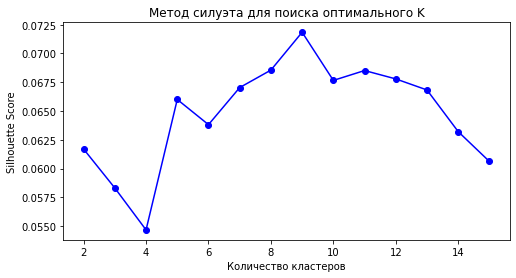

Наилучшее кол-во кластеров n_clusters = 9


In [24]:
# --- 2. Подбор числа кластеров (Silhouette Score) ---
# Используем TF-IDF матрицу (tfidf_matrix) из предыдущего этапа
sil_scores = []
range_n_clusters = range(2, 16) # Проверяем от 2 до 15 кластеров

for n in range_n_clusters:
    # Используем KMeans для быстрого подбора K
    clusterer = KMeans(n_clusters=n, random_state=42, n_init=10)
    preds = clusterer.fit_predict(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, preds)
    sil_scores.append(score)
    print(f"Для n_clusters = {n}, silhouette_score = {score:.4f}")

# Визуализация Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, sil_scores, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.title('Метод силуэта для поиска оптимального K')
plt.show()

# Выбираем лучший K и обучаем итоговую модель (пусть это будет 4, если score там выше)
best_k = range_n_clusters[np.argmax(sil_scores)]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_tfidf'] = kmeans.fit_predict(tfidf_matrix)

print(f"Наилучшее кол-во кластеров n_clusters = {best_k}")

In [25]:
# --- 3. Доминирующие слова в кластерах ---
def get_top_keywords(n_terms):
    """Возвращает топ-слова для каждого кластера"""
    terms = tfidf.get_feature_names_out()
    cluster_centers = kmeans.cluster_centers_
    
    for i in range(best_k):
        print(f"\nКластер {i}:")
        # Сортируем веса слов в центроиде кластера
        top_words_indices = cluster_centers[i].argsort()[-n_terms:][::-1]
        top_words = [terms[idx] for idx in top_words_indices]
        print(", ".join(top_words))

get_top_keywords(10)


Кластер 0:
like, gut, take, one, digestive, food, enzymes, right, get, going

Кластер 1:
fibra, ba, gomitas, si, dos, est, ir, vas, tres, voy

Кластер 2:
discount, tap, sale, cart, orange, shipping, get, ends, free, flash

Кластер 3:
fiber, like, gummies, get, day, need, one, two, eat, going

Кластер 4:
last, get, go, day, prices, automatically, apply, discounts, going, add

Кластер 5:
price, physicians, choice, üò, sale, get, today, bundle, gut, tiktok

Кластер 6:
probiotic, 60, capsules, supplement, developed, physician, doctors, choice, billion, enzymes

Кластер 7:
hoy, carrito, oferta, descuento, naranja, gratis, dos, precio, env, probi

Кластер 8:
probi, si, ticos, est, voy, olor, mal, aqu, va, ph


In [26]:
feature_tfidf = ['cluster_tfidf']

In [27]:
stats_df = df

stats_df['is_high'] = stats_df['revenue_category'] == "High"
stats_df['is_mid'] = stats_df['revenue_category'] == "Mid"
stats_df['is_low'] = stats_df['revenue_category'] == "Low"
stats_df['is_zero'] = stats_df['revenue_category'] == "Zero"

stats = stats_df.groupby('cluster_tfidf').agg(
    total_rows=('Video Revenue', 'count'),          # Кол-во строк
    total_revenue=('Video Revenue', 'sum'),        # Сумма выручки
    high=('is_high', 'sum'),     # Кол-во строк с условием "High"
    mid=('is_mid', 'sum'),
    low=('is_low', 'sum'),
    zero=('is_zero', 'sum')
).reset_index()

print(stats)

   cluster_tfidf  total_rows  total_revenue  high  mid  low  zero
0              0         517      415928.06     6   21  185   305
1              1         272      325476.58     9   35  137    91
2              2         290       37756.24     1    6   57   226
3              3         387       15977.37     0    4  124   259
4              4         111       21571.04     0    3   40    68
5              5         541       48918.32     0   14  125   402
6              6         130         712.16     0    0   19   111
7              7         289       26248.86     0    6   57   226
8              8         436      140062.04     3   21  127   285


# 7. Корреляция сформированных фичей с revenue

In [36]:
# Смотрим корреляцию с логарифмом revenue
correlations = df[feature_content + feature_sentiment + feature_tfidf + feature_marketing +
                  feature_lang + ['log_revenue']].corr()['log_revenue'].sort_values(ascending=False)
print("Корреляция признаков с log_revenue:")
print(correlations)

Корреляция признаков с log_revenue:
log_revenue             1.000000
has_hook                0.133671
is_product_mention      0.110076
ques_ratio              0.085827
mechanism_presence      0.084470
open_loop               0.071670
curiosity               0.053854
conv_score              0.048838
emotion_shift           0.044832
hook_len                0.044816
problem                 0.040370
selling_density         0.030935
question                0.030643
has_trust_signal        0.030447
sentiment_traj          0.007563
curiosity_gap           0.002721
avg_sent_len           -0.002537
product_mention_time   -0.017553
proof_presence         -0.022682
you_ratio              -0.072559
excl_ratio             -0.073839
authority              -0.084301
sales_count            -0.102141
lang_en                -0.118989
vader_sentiment        -0.134103
cluster_tfidf          -0.140004
bert_sentiment         -0.150325
caps_ratio             -0.163754
Name: log_revenue, dtype: float64


In [37]:
# Смотрим корреляцию с revenue_category
df_corr = df
df_corr['revenue_cat_encoded'] = df_corr['revenue_category'].astype('category').cat.codes
correlations = df_corr[feature_content + feature_sentiment + feature_tfidf + feature_marketing + feature_lang + 
                  ['revenue_cat_encoded']].corr(method='spearman')['revenue_cat_encoded'].sort_values(ascending=False)
print("Корреляция признаков с revenue_category:")
print(correlations)


Корреляция признаков с revenue_category:
revenue_cat_encoded     1.000000
has_hook                0.128782
is_product_mention      0.115838
selling_density         0.090375
mechanism_presence      0.088660
open_loop               0.066734
hook_len                0.064777
conv_score              0.062595
ques_ratio              0.055990
problem                 0.055320
emotion_shift           0.041627
curiosity               0.037024
has_trust_signal        0.029148
question                0.025632
avg_sent_len            0.011018
sentiment_traj          0.007258
curiosity_gap           0.001743
proof_presence         -0.004736
product_mention_time   -0.013820
you_ratio              -0.049235
authority              -0.076337
vader_sentiment        -0.088733
sales_count            -0.089805
lang_en                -0.102067
excl_ratio             -0.123709
bert_sentiment         -0.131610
cluster_tfidf          -0.136923
caps_ratio             -0.234648
Name: revenue_cat_encoded, dtype: f

# Итоговый список фичей

In [65]:
feature_names = feature_content + feature_sentiment + feature_tfidf + feature_marketing + feature_lang
print(feature_names)
print(len(feature_names))

['has_hook', 'excl_ratio', 'ques_ratio', 'caps_ratio', 'you_ratio', 'avg_sent_len', 'sales_count', 'is_product_mention', 'product_mention_time', 'has_trust_signal', 'vader_sentiment', 'bert_sentiment', 'cluster_tfidf', 'problem', 'curiosity', 'question', 'authority', 'hook_len', 'curiosity_gap', 'open_loop', 'mechanism_presence', 'proof_presence', 'selling_density', 'conv_score', 'sentiment_traj', 'emotion_shift', 'lang_en']
27


# 8. Выбор фичей (не обязательный пункт)

In [84]:
# 1. Формируем набор признаков (X) и таргет (y)
X = pd.concat([df[feature_names]], axis=1)
y = df['revenue_category']

# 2. Разделяем на обучающую и тестовую выборки
# Используем stratify=y, чтобы в обеих выборках было одинаковое соотношение категорий
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [85]:
# Установи библиотеку, если ее нет: !pip install mlxtend
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier

# Инициализируем модель
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Настраиваем SFS
sfs = SFS(clf, 
           k_features="best", # Искать наилучшее количество (от 1 до 13)
           forward=True,      # Прямой перебор (Forward Selection)
           floating=False,    # Можно поставить True для более сложного поиска
           scoring='f1_weighted', # Для несбалансированных классов лучше f1
           cv=3)              # Кросс-валидация на 3 фолда

# Запускаем перебор
sfs = sfs.fit(X[feature_names], y)

# Результаты
print(f"Лучшее сочетание фичей: {sfs.k_feature_names_}")
print(f"Лучший скор (F1): {sfs.k_score_}")

Лучшее сочетание фичей: ('ques_ratio', 'caps_ratio', 'avg_sent_len', 'sales_count', 'cluster_tfidf', 'curiosity', 'question', 'authority', 'hook_len', 'open_loop', 'mechanism_presence', 'proof_presence', 'selling_density', 'conv_score', 'lang_en')
Лучший скор (F1): 0.6215819724574015


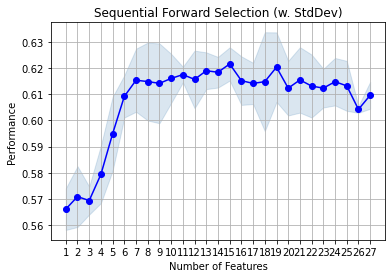

In [86]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev')
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

# 9. Подготовка данных и обучение модели

In [59]:
# 1. Формируем итоговый набор признаков (X) и таргет (y)
X = pd.concat([df[feature_names]], axis=1)
# Можно добавить только выбранные фичи на предыдущем шаге
# X = pd.concat([df[list(sfs.k_feature_names_)]], axis=1)
y = df['revenue_category']

# 2. Разделяем на обучающую и тестовую выборки
# Используем stratify=y, чтобы в обеих выборках было одинаковое соотношение категорий
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Обучаем модель
# class_weight='balanced' критически важен из-за дисбаланса классов
model = RandomForestClassifier(
    n_estimators=100, 
    #max_depth=10, 
    class_weight='balanced', 
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [60]:
# 4. Предсказание
y_pred = model.predict(X_test)

# 10. Оценка качества (Confusion Matrix)

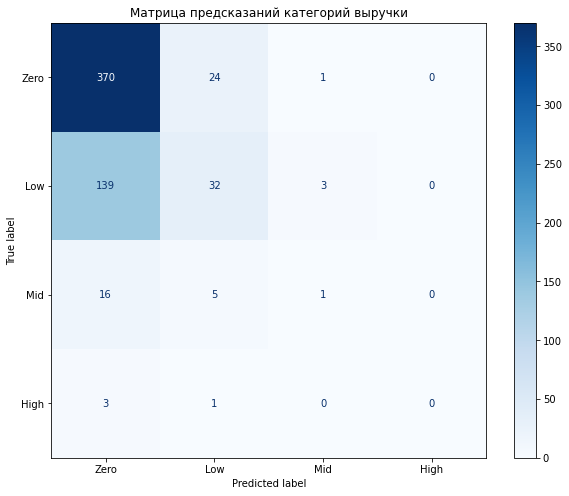

              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.52      0.18      0.27       174
         Mid       0.20      0.05      0.07        22
        Zero       0.70      0.94      0.80       395

    accuracy                           0.68       595
   macro avg       0.35      0.29      0.29       595
weighted avg       0.62      0.68      0.61       595

Weighted F1-Score: 0.6142870487976017


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
# Визуализация матрицы ошибок
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=labels, cmap='Blues', ax=ax)
plt.title('Матрица предсказаний категорий выручки')
plt.show()

# Отчет по метрикам
print(classification_report(y_test, y_pred))

weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1-Score: {weighted_f1}")

# 11. Обработка дисбаланса классов

In [94]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [95]:
print(X_res.shape)
print(X_train.shape)

(6312, 27)
(2378, 27)


In [96]:
model = RandomForestClassifier(
    n_estimators=100, 
    #max_depth=10, 
    class_weight='balanced', 
    random_state=42
)
model.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [97]:
# 4. Предсказание
y_pred = model.predict(X_test)

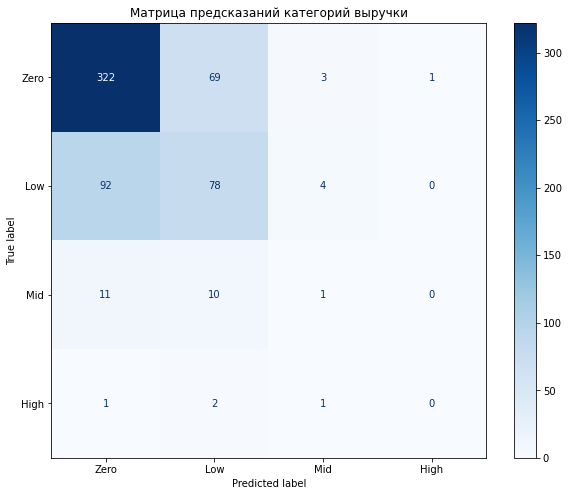

              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.49      0.45      0.47       174
         Mid       0.11      0.05      0.06        22
        Zero       0.76      0.82      0.78       395

    accuracy                           0.67       595
   macro avg       0.34      0.33      0.33       595
weighted avg       0.65      0.67      0.66       595

Weighted F1-Score: 0.6601252518801117


In [98]:
# Визуализация матрицы ошибок
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=labels, cmap='Blues', ax=ax)
plt.title('Матрица предсказаний категорий выручки')
plt.show()

# Отчет по метрикам
print(classification_report(y_test, y_pred))

weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1-Score: {weighted_f1}")

# 12. Интерпретация важности признаков

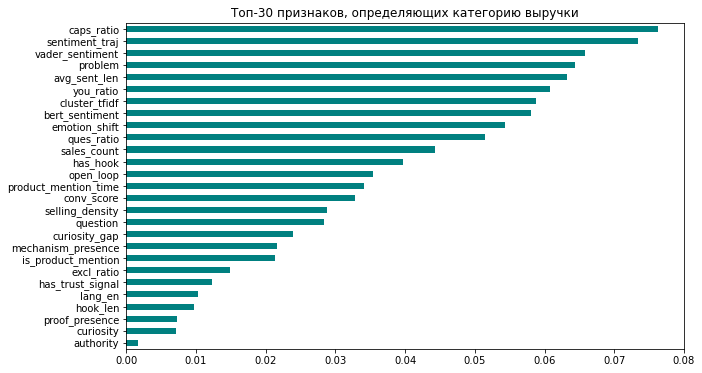

In [99]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.nlargest(30)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='teal')
plt.title('Топ-30 признаков, определяющих категорию выручки')
plt.gca().invert_yaxis()
plt.show()

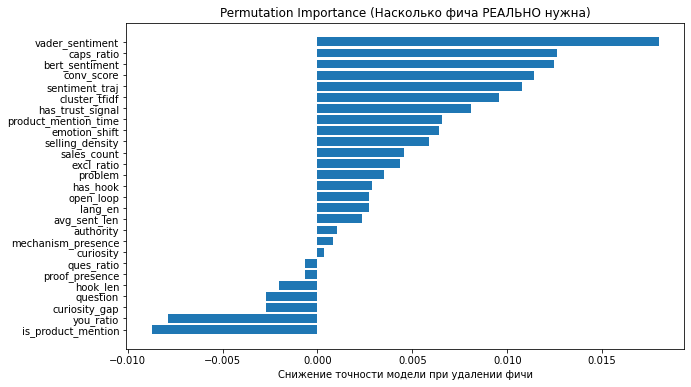

In [100]:
from sklearn.inspection import permutation_importance

# Вычисляем важность через перестановки
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Визуализация
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Снижение точности модели при удалении фичи")
plt.title("Permutation Importance (Насколько фича РЕАЛЬНО нужна)")
plt.show()

In [101]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Важно: обучаем скейлер только на TRAIN, а трансформируем и TRAIN, и TEST
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Для RFE лучше использовать линейную модель и Скейлинг
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
rfe = RFE(estimator=lr, n_features_to_select=10) # Оставим топ-10 самых важных
rfe.fit(X_train_scaled, y_train)

# Посмотрим, какие фичи важнее
supported_features = pd.DataFrame({
    'Feature': X.columns,
    'Keep': rfe.support_,
    'Rank': rfe.ranking_
}).sort_values(by='Rank')

#supported_features.to_csv('supported_features.csv')

In [102]:
print(supported_features.head(30))

                 Feature   Keep  Rank
0               has_hook   True     1
24        sentiment_traj   True     1
20    mechanism_presence   True     1
17              hook_len   True     1
16             authority   True     1
12         cluster_tfidf   True     1
13               problem   True     1
26               lang_en   True     1
1             excl_ratio   True     1
3             caps_ratio   True     1
4              you_ratio  False     2
7     is_product_mention  False     3
8   product_mention_time  False     4
5           avg_sent_len  False     5
25         emotion_shift  False     6
15              question  False     7
10       vader_sentiment  False     8
23            conv_score  False     9
18         curiosity_gap  False    10
11        bert_sentiment  False    11
2             ques_ratio  False    12
19             open_loop  False    13
21        proof_presence  False    14
6            sales_count  False    15
14             curiosity  False    16
9       has_

# 13. Probability/confidence score

In [103]:
# 1. Получаем вероятности для всех классов
probabilities = model.predict_proba(X_test)

# 2. Создаем DataFrame с результатами
results = pd.DataFrame(probabilities, columns=model.classes_)

# 3. Добавляем предсказанный класс и реальный класс
results['Predicted'] = y_pred
results['Actual'] = y_test.values

# 4. Добавляем Confidence Score (максимальная вероятность среди всех классов)
results['Confidence'] = results[['Zero', 'Low', 'Mid', 'High']].max(axis=1)

# Используем индексы X_test, чтобы вытащить данные из оригинального df
results['URL'] = df.loc[X_test.index, 'URL'].values
results['Video Revenue'] = df.loc[X_test.index, 'Video Revenue'].values
results['Transcript'] = df.loc[X_test.index, 'Transcript'].values

# Выведем примеры, где модель наименее уверена в успехе
display(results[results['Actual'].isin(['High', 'Mid'])].sort_values(by='Confidence', ascending=True).head(25))



,High,Low,Mid,Zero,Predicted,Actual,Confidence,URL,Video Revenue,Transcript
25,0.05,0.390,0.30,0.260,Low,Mid,0.390,https://tiktok.com/@historiasdeperrosygato/vid...,1126.73,"antes, ahora\nantes\nahora\nt?? est?°s viendo ..."
525,0.00,0.350,0.25,0.400,Zero,Mid,0.400,https://tiktok.com/@legendarylootfinds/video/7...,6558.71,YO\n70% off today\n70%\nYou're only paying 30%...
364,0.00,0.410,0.17,0.420,Zero,Mid,0.420,https://tiktok.com/@ana.wellness/video/7598039...,4935.91,"Mi amor, si t?? est?°s viendo esto all?° abajo..."
360,0.07,0.420,0.27,0.240,Low,Mid,0.420,https://tiktok.com/@that.girl.wellnesstips/vid...,1531.96,Si quieres limpiar tu intestino hasta de lo qu...
260,0.00,0.365,0.21,0.425,Zero,Mid,0.425,https://tiktok.com/@luxurious.listing/video/75...,1206.95,remember that it's alright alright alright\nda...
284,0.00,0.240,0.33,0.430,Zero,Mid,0.430,https://tiktok.com/@ofertas_tiktok_oficial/vid...,1483.83,"No lo compres, cuidado, no te vayas a comprar ..."
304,0.05,0.310,0.21,0.430,Zero,Mid,0.430,https://tiktok.com/@gigigonza7/video/759460928...,4656.08,"Pregunta seria, ¬øokay? Tu hijo tiene mal alie..."
392,0.00,0.435,0.14,0.425,Low,Mid,0.435,https://tiktok.com/@althegirlsgal/video/758529...,7099.41,You don't have a gallbladder. Me neither. Than...
206,0.02,0.450,0.39,0.140,Low,Mid,0.450,https://tiktok.com/@lyshopdeals/video/75891280...,3545.37,"La semana pasada, hoy, la semana pasada, hoy y..."
517,0.08,0.470,0.24,0.210,Low,High,0.470,https://tiktok.com/@tips.de.suplement/video/75...,17750.10,"Si quieres hacer del dos, o sea de la caca, pe..."


# 14. Использование эмбеддингов (Embeddings)

In [78]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [79]:
# ------------------------------------------------------
# 3. Генерируем эмбеддинги (на CPU)
# ------------------------------------------------------
model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
# Альтернатива: 'intfloat/multilingual-e5-small'

model = SentenceTransformer(model_name)
print(f"Модель загружена: {model_name}")

transcripts = df['Transcript'].fillna("").tolist()  # на всякий случай убираем NaN

embeddings = model.encode(
    transcripts,
    batch_size=64,                # можно 32–128 в зависимости от RAM
    show_progress_bar=True,
    device='cpu',
    normalize_embeddings=True     # cosine similarity будет стабильнее
)

# embeddings.shape → (n_rows, 384) или (n_rows, 1024) в зависимости от модели


Модель загружена: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

In [80]:
embeddings.shape

(2973, 384)

In [81]:
# ------------------------------------------------------
# 4. Готовим X и y
# ------------------------------------------------------
# Берём числовые фичи как numpy-массив
extra_features = df[feature_names].to_numpy()
# Объединяем горизонтально (по столбцам)
X = np.hstack([embeddings, extra_features, tfidf_df.to_numpy()])
y = df['revenue_category']

# Разделяем (stratify — важно для несбалансированных классов!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------
# 5. Обучаем классификатор
# ------------------------------------------------------
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1,           # все ядра CPU
    class_weight='balanced'  # помогает при сильном дисбалансе
)

clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [82]:
X.shape

(2973, 911)


Weighted F1-score: 0.6023801569557486

Classification Report:

              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.57      0.14      0.23       174
         Mid       0.00      0.00      0.00        22
        Zero       0.69      0.96      0.81       395

    accuracy                           0.68       595
   macro avg       0.32      0.28      0.26       595
weighted avg       0.63      0.68      0.60       595


Confusion Matrix:


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


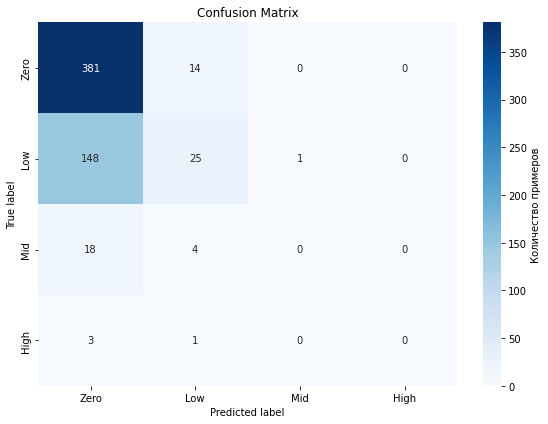

In [83]:
# ------------------------------------------------------
# 6. Оцениваем
# ------------------------------------------------------
y_pred = clf.predict(X_test)

print("\nWeighted F1-score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")

# Вычисляем матрицу
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Нормализованная версия (в процентах) — часто выглядит лучше
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Рисуем
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,                          # или cm_percent, если хочешь проценты
    annot=True,                  # показывать числа в ячейках
    fmt='d',                     # 'd' = целые числа; для процентов → '.1f' или '.1%'
    cmap='Blues',                # или 'YlGnBu', 'Greens', 'viridis' и т.д.
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Количество примеров'}  # подпись цветовой шкалы
)

plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()
